# Ch13. 해석성

(\*) 복잡한 머신러닝 모델을 화이트박스화하려는 시도:
- 전역적 모델: 모델이 학습된 후 예측을 구성하는 데 있어 특성의 ㅈ상대적인 역할 결정하려 함
$\\ \rarr$ 해석에서 보이는 패턴이 전체 훈련셋에 걸쳐 평균적으로 유지됨
- 지역적 모델: 인스턴스 주변의 작은 변화 고려해 모델이 특정 상황에서 어떻게 작동하는지 특성화함 ~ 선형 방식 등으로 근사화해 모델을 단순화함

[13.1] 전역적 해석
13.1.1 대리 모델로서의 단순 모형
- 선형모델: $y_i=\alpha+\sum_{k=1}^K\beta_kx_i^k+\epsilon_i$
$\\$By $\beta_k$ 추정:
- 모델의 전체 적합도 평가하는 $R^2$ 추출
- $y$에 대한 각 특성 $x^k$의 영향에 대한 부호를 나타내는 $\hat{\beta}_k$의 부호
- 이 영향의 크기를 평가하는 $t$-통계량 $t_{\hat{\beta}_k}$
- 의사결정 트리: 그림으로 표현하기 쉬움 => 단순한 모델 위한 벤치마킹 대상으로 사용됨
- 복잡한 알고리듬 프록시 => by 대리모델(surrogate model) 구축:
1. 특성 $X$와 레이블 $y$에 대해 원래 모델 $f$를 훈련함
2. 특성 $X$가 주어졌을 때 훈련된 모델 $\hat{f}$의 예측을 설명하기 위해 더 간단한 모델 $g$를 훈련함
$\\ \hat{f}(X)=g(X)+\text{오차항}$
- 추정 모델 $\hat{g}$: 초기 모델이 특성을 레이블에 매핑하는 방법을 설명함

In [ ]:
import import_ipynb

In [ ]:
from Ch6 import fit_tree, fit_RF, fit_xgb

In [ ]:
'''
# 트리의 예측을 새로운 타깃으로 저장
new_target=fit_RF.predict(X_short)
# 전역적 해석이 가능한 트리 대리 모델 정의
decision_tree_model=tree.DecisionTreeRegressor(max_depth=3)
# 대리 모델 피팅
TreeSurrogate=decision_tree_model.fit(X_short, new_target)
# 차트 매개 변수 세팅
fig, ax=plt.subplots(figsize=(13,8))
tree.plot_tree(TreeSurrogate, feature_names=features_short, ax=ax)
plt.show()
'''

In [ ]:
from Ch1 import features_short

In [ ]:
import pandas as pd
import numpy as np
'''
# 트리 모델 변수 중요도
tree_VI=pd.DataFrame(data=fit_tree.features_importances_,index=features_short, columns=['Tree'])
# 랜덤 포레스트 변수 중요도
RF_VI=pd.DataFrame(data=fit_RF.feature_importances_, index=features_short, columns=['RF'])
# 부스트 트리 변수 중요도
XGB_VI=pd.DataFrame(data=fit_xgb.feature_importances_, index=features_short, columns=['XGB'])
VI_trees=pd.concat([tree_VI, RF_VI, XGB_VI], axis=1)
VI_trees=VI_trees.loc[['Mkt_Cap_12M_Usd', 'Pb', 'Vol1Y_Usd']]/np.sum(VI_trees.loc[['Mkt_Cap_12M_Usd', 'Pb', 'Vol1Y_Usd']])
VI_trees.plot.bar(figsize=[10,6])
'''

[13.1.3] 불가지론적 변수 중요도
- 하나의 특성이 학습 프로세스에 어느 정도 기여하는지 정량화하는 것이 목표
- 훈련 집합 내에서 해당 특성 값이 완전히 섞일 경우 손실이 어떻게 변하는지 확인

In [4]:
from Ch1 import data_ml, features
from Ch5 import training_sample
import numpy as np

y_penalized=data_ml['R1M_Usd'].values
X_penalized=data_ml[features].values

y_penalized_train=training_sample['R1M_Usd'].values
X_penalized_train=training_sample[features].values
from sklearn.linear_model import Ridge
fit_ridge_0=Ridge(alpha=0.01)
fit_ridge_0.fit(X_penalized_train, y_penalized_train)
l_star=np.mean(np.square(fit_ridge_0.predict(X_penalized_train)-y_penalized_train)) # 손실


<Axes: xlabel='feat'>

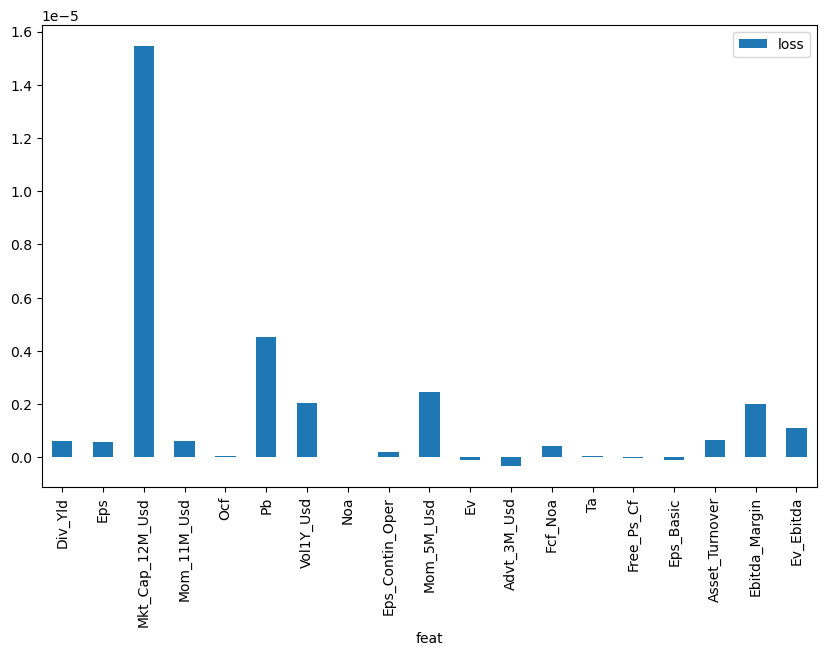

In [7]:
from collections import Counter
import random
from Ch1 import features_short
import pandas as pd
res=[]
# 몇 가지 특성만 선택
feature_random=random.sample(list((Counter(features)-Counter(features_short)).elements()), 12)
# 특성에 대한 루프
for feat in (features_short+feature_random):
    temp_data=training_sample[features].copy()
    # feat[i] 셔플링
    temp_data.loc[:,feat]=np.random.permutation(training_sample[feat])
    fit_ridge_0.fit(temp_data[features], training_sample['R1M_Usd'])
    result_VI=pd.DataFrame([feat], columns=['feat'])
    result_VI['loss']=[np.mean(np.square(fit_ridge_0.predict(
        temp_data[features])-training_sample['R1M_Usd']
        ))-l_star]
    res.append(result_VI)
res=pd.concat(res)
res.set_index('feat', inplace=True)
res.plot.bar(figsize=[10,6])

[13.1.4] 부분 종속성 플롯
- 모델의 출력과 특성값 사이의 관계를 보여줌
- 특성 k 고정 & 훈련된 모델의 예측에 대한 k의 평균 영향 이해
- 무작위 공간, 특성 공간: k / -k 로 구분
$\\ \bar{f}_k(x_k)=\mathbb{E}[\hat{f}(\textbf{x}_{-k},x_k)]=\int \hat{f}(\textbf{x}_{-k},x_k)d\mathbb{P}_{-k}(\textbf{x}_{-k})$: 특성 k의 영향만 보여줌

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

[13.2] 지역적 해석
- 특정 인스턴스 or 그 주변에서 모델의 동작을 정량화하려 함
[13.2.1] LIME
- 단순 해석성
- 지역적 충실도
$\\ \xi(x)=\underset{g \in G}{\text{argmin}} \, \mathcal{L}(f,g,\pi_x)+\Omega(g)$
- $\mathcal{L}(f,g,\pi_x)$: x의 부근 pi_x에서 g에 의해 유도되는 손실함수
- x의 주변부: $\pi_x(z)=e^{-D(x,z)^2/\sigma^2}$ ~ z가 x에서 멀어질 때 감소함
- 손실함수: $\mathcal{L}(f,g,\pi_x)=\sum_z \pi_x(z)(f(z)-g(z))^2$ ~ x와의 거리에 따라 가중치 부여
- 모델 집합 G: 선형 모델로 구성됨

In [8]:
!pip install lime

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283917 sha256=05bfeb0af85286119bb1cba86ffac43c83fc29ad7cfc62d429ab971348302ae1
  Stored in directory: c:\users\82103\appdata\local\pip\cache\wheels\7c\04\5c\157dc9106512a6c7a30653ec064490c94a49e0fc8f63d19ab9
Successfully built lime


In [9]:
# Step1. 모델 피팅
import lime
import lime.lime_tabular
import xgboost

xgb_model=xgboost.XGBRegressor(
    max_depth=5,
    learning_rate=0.5,
    objective='reg:squarederror',
    subsample=1,
    colsample_bytre=1,
    gamma=0.1,
    n_estimators=10,
    min_child_weight=10
)
train_features_xgb=training_sample.loc[:, features_short]
train_label_xgb=training_sample.loc[:,'R1M_Usd']
xgb_model.fit(train_features_xgb, train_label_xgb)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [10]:
# 2. Lime 함수로 래핑
explainer=lime.lime_tabular.LimeTabularExplainer(
    train_features_xgb.values, mode='regression', feature_names=train_features_xgb.columns, verbose=1
)

c:\Users\82103\anaconda3\Lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
c:\Users\82103\anaconda3\Lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
c:\Users\82103\anaconda3\Lib\site-packages\lime\lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, 

Intercept 0.008982562431866785
Prediction_local [0.02620369]
Right: 0.0192975


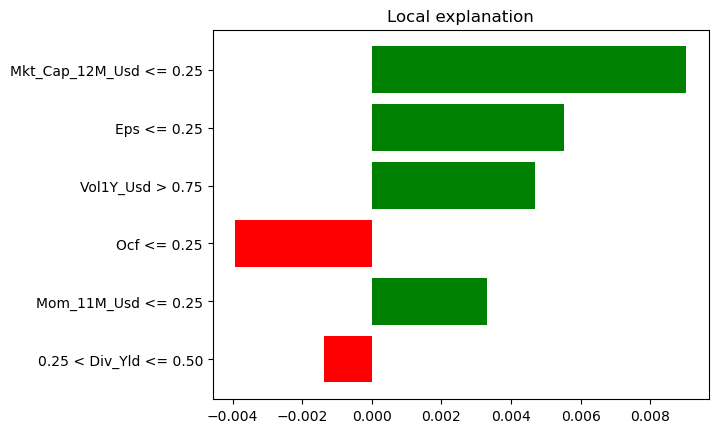

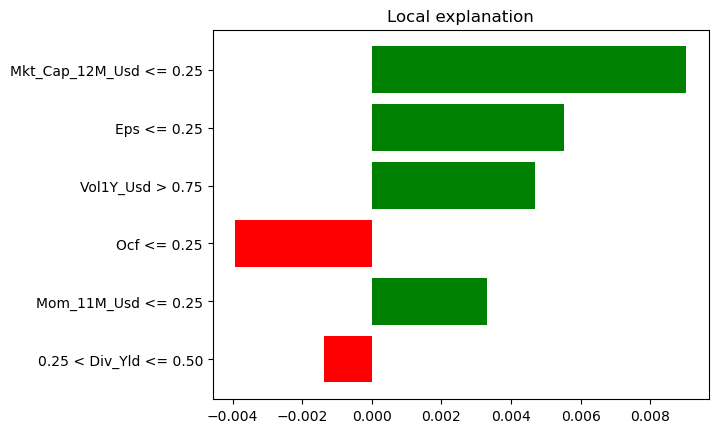

In [16]:
# 3. 몇 가지 예측 변수에 집중
exp=explainer.explain_instance(train_features_xgb.iloc[0,:],
                               predict_fn=xgb_model.predict,
                               labels=train_label_xgb.iloc[0],
                               distance_metric='euclidean',
                               num_samples=900,
                               num_features=6)
exp.as_pyplot_figure()

[13.2.2] 샤플리 값
- 변수의 영향력 평가: 데이터셋에서 해당 변수 제거하면 어떤 일이 일어나는지 확인
$\\ \phi_k=\sum_{S \subseteq \{x_1,\dots,x_K \} \backslash x_k}\underbrace{\frac{\text{Card}(S)!(K-\text{Card}(S)-1)!}{K!}}_{\text{weight of coalition}}\underbrace{\left(\hat{f}_{S \cup \{x_k\}}(S \cup \{x_k\})-\hat{f}_S(S)\right)}_{\text{gain when adding } x_k}$

In [17]:
from sklearn.ensemble import RandomForestRegressor
fit_RF_short=RandomForestRegressor(
    n_estimators=40, # 랜덤 트리 개수
    criterion='squared_error',
    min_samples_leaf=250,
    max_features=4,
    bootstrap=True,
    max_samples=10000
)
fit_RF_short.fit(training_sample[features_short], training_sample['R1M_Usd'].values)

,n_estimators,40
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,250
,min_weight_fraction_leaf,0.0
,max_features,4
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
!pip install shap

   ---------------------------------------- 0.0/549.1 kB ? eta -:--:--
   ---------------------------------------- 549.1/549.1 kB 11.0 MB/s  0:00:00

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



c:\Users\82103\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
ExactExplainer explainer: 2it [00:11, 11.70s/it]               


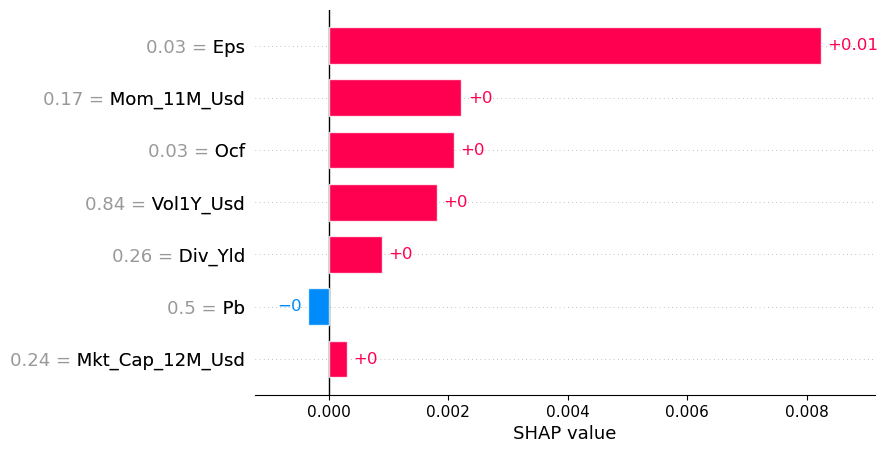

In [20]:
import shap
explainer=shap.explainers.Exact(fit_RF_short.predict,
                                training_sample[features_short].values,
                                feature_names=features_short)
shap_values=explainer(training_sample[features_short].values[:1,])
shap.plots.bar(shap_values[0])

[13.2.3] 분해
- PDP+샤플리 값
- 완화된 모델 예측
- 하나의 특정 관측치에서 작업
$\\ \tilde{f}_{\textbf{k}}(x^*)=\frac{1}{M}\sum_{m=1}^M \hat{f}\left(x^{(m)}_{-\textbf{k}},x^*_{\textbf{k}} \right)$
$\\ \phi_{\textbf{k}}^j(x^*)=\tilde{f}_{\textbf{k} \cup j}(x^*)-\tilde{f}_{\textbf{k}}(x^*)$: 특성 j로 예측 인자 집합을 보강할 때 평균 영향 계산
$\\ \sum_j \phi_{\textbf{k}}^j(x^*)=f(x^*)$

In [21]:
fit_RF_short=RandomForestRegressor(
    n_estimators=12,
    criterion='squared_error',
    min_samples_leaf=250,
    max_features=4,
    bootstrap=True,
    max_samples=10000
    )
fit_RF_short.fit(training_sample[features_short], training_sample['R1M_Usd'].values)

,n_estimators,12
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,250
,min_weight_fraction_leaf,0.0
,max_features,4
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
!pip install dalex

   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/1.0 MB 16.9 MB/s  0:00:00


In [24]:
import dalex as dx
ex=dx.Explainer(
    model=fit_RF_short,
    data=training_sample[features_short],
    y=training_sample['R1M_Usd'].values,
    label='fit_RF_short'
)
instance=pd.DataFrame(training_sample.loc[0, features_short]).T
pp=ex.predict_parts(instance, type='break_down')
pp.plot()

Preparation of a new explainer is initiated

  -> data              : 198128 rows 7 cols
  -> target variable   : 198128 values
  -> model_class       : sklearn.ensemble._forest.RandomForestRegressor (default)
  -> label             : fit_RF_short
  -> predict function  : <function yhat_default at 0x000001E712DCF240> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = -0.0123, mean = 0.0146, max = 0.0799
  -> model type        : regression will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.939, mean = -0.000642, max = 27.2
  -> model_info        : package sklearn

A new explainer has been created!
